# PYTHON EXPLORATORY DATA ANALYSIS (EDA)
------------------------------------------------------------

#### BUSINESS CONTEXT:
After completing SQL-based business analysis, Python EDA will be used
to investigate the Ashbourne & Co. dataset at a deeper analytical level.

The objective is to uncover sales trends, profitability patterns,
customer behavior, store performance, operational inefficiencies,
product pricing relationships, and marketing effectiveness.

Python will be used to combine statistical analysis with visualizations
to identify hidden patterns, anomalies, outliers, correlations, and
potential business opportunities before proceeding to machine learning
or advanced analytics.

The analysis should use appropriate Pandas, NumPy, Matplotlib, Seaborn,
and statistical techniques wherever required.

------------------------------------------------------------
SALES & PROFITABILITY
------------------------------------------------------------

1. MONTHLY NET SALES TREND

BUSINESS QUESTION:
How does monthly Net Sales change over time, and is Ashbourne & Co.
overly dependent on Q4 sales?

EDA TASK:
Plot monthly Net Sales using a line chart and identify seasonal
patterns, peaks, declines, and potential Q4 sales concentration.


2. PROFIT DISTRIBUTION BY PRODUCT CATEGORY

BUSINESS QUESTION:
How does profit vary across product categories, and are there any
extreme profit or margin outliers?

EDA TASK:
Create a boxplot of Profit per Order by Product Category to identify
differences in distribution, variability, and extreme profit values.


3. OVERALL RETURN RATE

BUSINESS QUESTION:
What percentage of orders are returned, and how significant are
returns to the overall business?

EDA TASK:
Calculate the overall Return Rate percentage and visualize the
proportion of Returned vs Completed orders using a pie chart.


4. DISCOUNT DISTRIBUTION

BUSINESS QUESTION:
What discount levels are most commonly applied to transactions?

EDA TASK:
Create a histogram of Discount Percentage across all transactions
to understand the distribution of discounts and identify unusually
high discount levels.


5. GROSS SALES VS NET SALES

BUSINESS QUESTION:
How much revenue is lost through discounts for the highest-performing
product sub-categories?

EDA TASK:
Identify the Top 5 sub-categories based on Net Sales and compare their
Gross Sales vs Net Sales using a grouped bar chart.


------------------------------------------------------------
CUSTOMER BEHAVIOR
------------------------------------------------------------

6. CUSTOMER RFM ANALYSIS

BUSINESS QUESTION:
Who are the most valuable customers, and how can customers be
segmented based on purchasing behavior?

EDA TASK:
Calculate Recency, Frequency, and Monetary (RFM) metrics for each
customer. Assign RFM scores and create customer segments.

Visualize the size of each customer segment using an appropriate
bar chart or count plot.


7. CUSTOMER AGE DISTRIBUTION

BUSINESS QUESTION:
What is the age profile of Ashbourne & Co.'s customer base?

EDA TASK:
Create a histogram of Customer Age with a KDE curve to understand
the central age distribution, concentration, and spread of customers.


8. CUSTOMER LOYALTY TIER DISTRIBUTION

BUSINESS QUESTION:
How are customers distributed across the different Loyalty Tiers?

EDA TASK:
Create a count plot showing the number of customers in each
Loyalty Tier and identify the relative size of each tier.


9. AVERAGE ORDER VALUE BY INCOME BRACKET

BUSINESS QUESTION:
Does customer income level influence Average Order Value (AOV)?

EDA TASK:
Calculate Average Order Value for each Income Bracket and visualize
the results using a bar chart with error bars to show variability.


10. CUSTOMER ACQUISITION SOURCE

BUSINESS QUESTION:
Which acquisition channels contribute the highest number of customers
and how effectively is the customer base distributed across channels?

EDA TASK:
Calculate the number of customers acquired through each Acquisition
Source and visualize the results using a horizontal bar chart.


------------------------------------------------------------
STORES & OPERATIONS
------------------------------------------------------------

11. E-COMMERCE DELIVERY TIME

BUSINESS QUESTION:
How efficiently are e-commerce orders being delivered, and what does
the distribution of delivery time look like?

EDA TASK:
Calculate Delivery Time in Days for e-commerce orders using the
Order Date and Delivery Date.

Plot the distribution of delivery time to identify the average,
spread, and unusually long delivery durations.


12. STOCK LEVEL BY STORE TYPE

BUSINESS QUESTION:
How is physical inventory distributed across different store types?

EDA TASK:
Calculate the total physical Stock Level for each Store Type and
visualize the comparison using a donut chart.


13. STORE SPACE VS REVENUE

BUSINESS QUESTION:
Does larger store space translate into higher revenue?

EDA TASK:
Aggregate Store Square Footage and Total Revenue at the store level.

Create a scatter plot comparing Store Square Footage against Total
Revenue to investigate the relationship between physical space and
sales performance.


14. ORDER STATUS BY STORE CITY

BUSINESS QUESTION:
How do Completed and Returned orders vary across different store
locations?

EDA TASK:
Aggregate orders by Store City and Order Status.

Create a stacked bar chart showing Completed vs Returned orders
for each city.


15. LOW-RATING ORDERS BY STORE

BUSINESS QUESTION:
Which stores receive the highest volume of low-rated orders and may
require further investigation?

EDA TASK:
Identify orders with ratings of 1 or 2, aggregate them by store,
and identify the Top 3 stores with the highest number of low-rating
orders.

Visualize the results using a bar chart.


------------------------------------------------------------
PRODUCTS & MARKETING
------------------------------------------------------------

16. UNIT COST VS RETAIL PRICE

BUSINESS QUESTION:
How are product costs related to their retail prices, and what does
the pricing structure look like across the product portfolio?

EDA TASK:
Analyze the distribution and relationship between Unit Cost and
Retail Price using a joint plot.


17. MARKETING CHANNEL REVENUE

BUSINESS QUESTION:
Which marketing channels generate the highest attributed revenue?

EDA TASK:
Aggregate Net Revenue generated by Marketing Campaign Channel and
visualize the results using a bar chart.


18. PRODUCT MATERIAL VS CUSTOMER RATING

BUSINESS QUESTION:
Does product Material type have any noticeable relationship with
customer ratings?

EDA TASK:
Calculate the average customer Rating for each Material type and
visualize the results using a bar chart.


19. CAMPAIGN BUDGET VS ACTUAL REVENUE

BUSINESS QUESTION:
Is higher marketing campaign spending associated with higher
attributed revenue?

EDA TASK:
Compare Campaign Budget against Actual Revenue using a scatter plot
with a regression line to examine the relationship between marketing
investment and revenue.


20. CAMPAIGN LAUNCH TIMING VS ORDER VOLUME

BUSINESS QUESTION:
Do marketing campaign launch dates coincide with changes in daily
order volume?

EDA TASK:
Create a daily time-series plot of order volume and mark Campaign
Start Dates on the timeline to visually investigate potential
relationships between campaign launches and customer purchasing
activity.


------------------------------------------------------------
EDA OBJECTIVE
------------------------------------------------------------

The Python EDA should ultimately identify:

• Sales seasonality and Q4 dependency

• Profitability differences across categories

• Return and discount patterns

• High-value customer segments

• Customer demographic and loyalty patterns

• Acquisition channel distribution

• E-commerce delivery performance

• Inventory distribution across stores

• Relationship between store size and revenue

• Store-level customer experience issues

• Product pricing and material patterns

• Marketing channel and campaign performance

• Potential relationships between marketing investment and revenue

The findings from this EDA will be used to support business
recommendations and determine which areas require deeper statistical
analysis or machine learning.

### Importing required packages

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import math as math
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

import pyodbc

### Connecting to sql server to import data

In [6]:
# Finding ODBC Driver

print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [7]:
# ============================================================
# 1. SQL Server connection
# ============================================================

server = r"DESKTOP-0SIEUH6\SQLEXPRESS"
database = "AshbourneCo"

conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

# ============================================================
# 2. Get all tables from dbo schema
# ============================================================

tables_query = """
SELECT TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_SCHEMA = 'dbo'
  AND TABLE_TYPE = 'BASE TABLE'
ORDER BY TABLE_NAME;
"""

tables = pd.read_sql(tables_query, conn)

print("Tables found:")
print(tables)

Tables found:
            TABLE_NAME
0            customers
1            inventory
2  marketing_campaigns
3               orders
4             products
5               stores


### Importing datasets from sql server in form of tables

In [8]:
# Dictionary to hold all DataFrames
dataframes = {}

for table_name in tables["TABLE_NAME"]:
    
    query = f"SELECT * FROM dbo.[{table_name}]"
    
    dataframes[table_name] = pd.read_sql(query, conn)
    
    # Create a variable with the same name as the SQL table
    globals()[table_name] = dataframes[table_name]
    
    print(f"{table_name}: {dataframes[table_name].shape}")

customers: (3000, 8)
inventory: (1024, 5)
marketing_campaigns: (34, 6)
orders: (26500, 16)
products: (64, 8)
stores: (16, 6)


####
### 1. MONTHLY NET SALES TREND

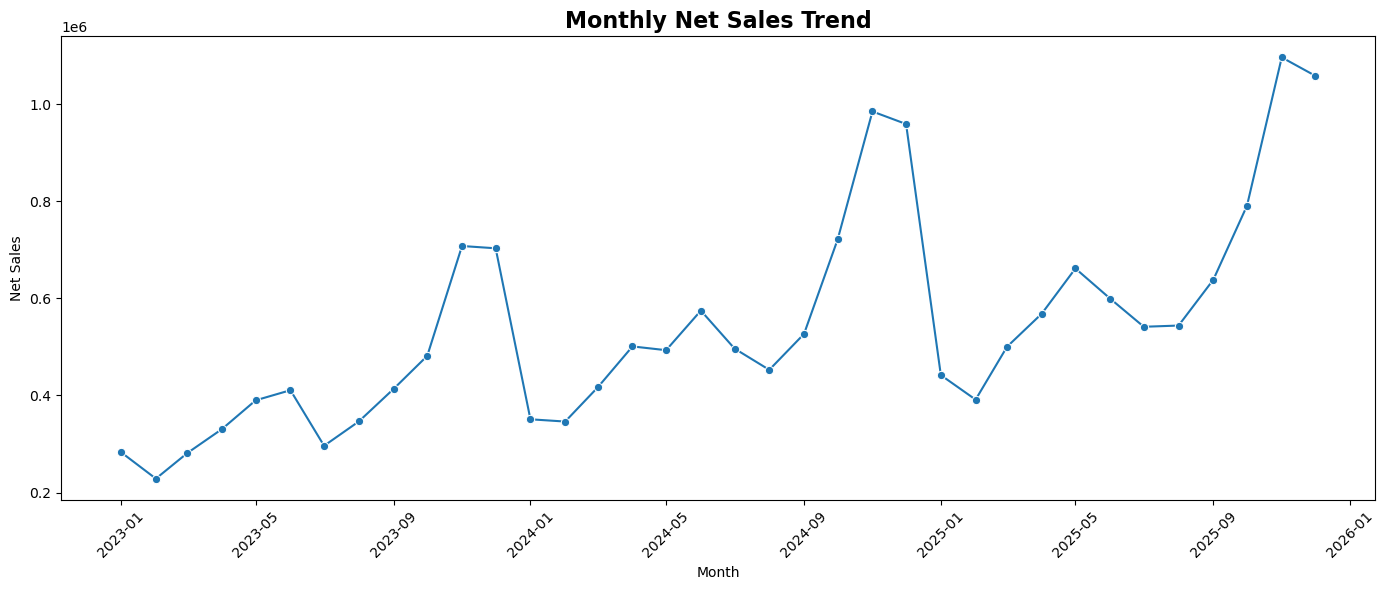

Total Net Sales: 19,524,324.95
Q4 Net Sales: 7,501,161.03
Q4 Sales Contribution: 38.42%


In [10]:
# Ensure order_date is datetime
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Monthly Net Sales
monthly_sales = (
    orders
    .groupby(orders["order_date"].dt.to_period("M"))["net_sales"]
    .sum()
    .reset_index()
)

monthly_sales["order_date"] = monthly_sales["order_date"].dt.to_timestamp()

# Plot
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="order_date",
    y="net_sales",
    marker="o"
)

plt.title("Monthly Net Sales Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




# Q4 Sales Analysis
monthly_sales["month"] = monthly_sales["order_date"].dt.month
monthly_sales["quarter"] = monthly_sales["order_date"].dt.quarter

q4_sales = monthly_sales.loc[
    monthly_sales["quarter"] == 4,
    "net_sales"
].sum()

total_sales = monthly_sales["net_sales"].sum()

q4_sales_percentage = (q4_sales / total_sales) * 100

print(f"Total Net Sales: {total_sales:,.2f}")
print(f"Q4 Net Sales: {q4_sales:,.2f}")
print(f"Q4 Sales Contribution: {q4_sales_percentage:.2f}%")



####
### 2. PROFIT DISTRIBUTION BY PRODUCT CATEGORY

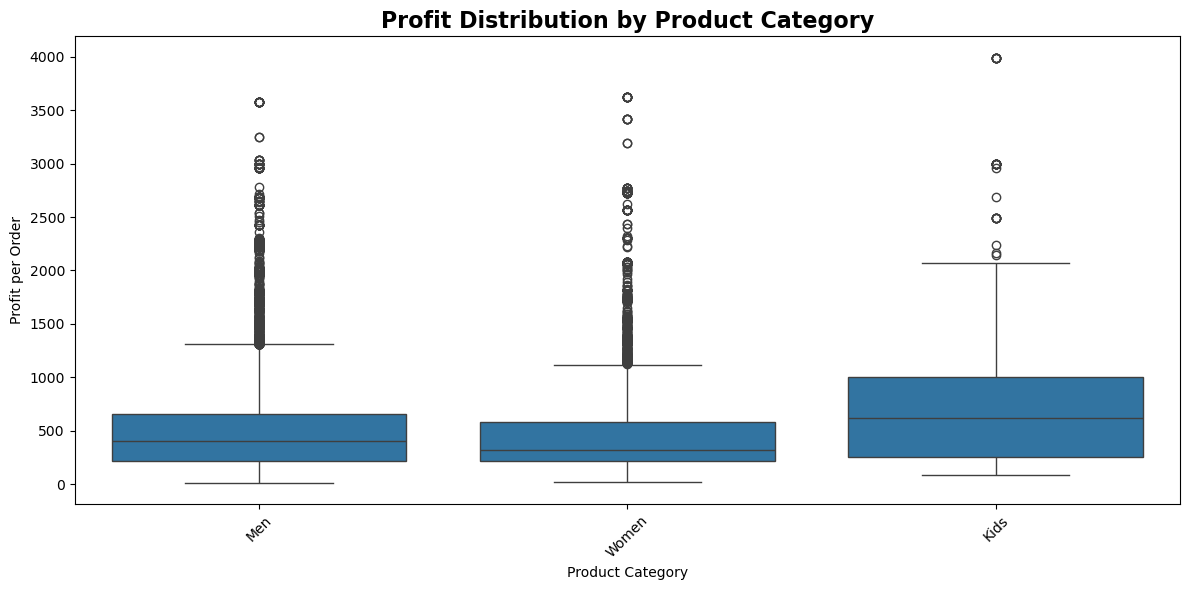

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Kids,1190.0,745.38,586.67,83.79,253.35,622.49,998.46,3993.84
Men,15248.0,510.39,447.51,12.49,218.13,407.60,653.81,3578.68
Women,10062.0,463.98,415.46,16.63,215.66,318.91,580.55,3628.68


In [11]:
# Merge Orders with Products to obtain Category
profit_category = orders.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

# Boxplot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=profit_category,
    x="category",
    y="profit"
)

plt.title("Profit Distribution by Product Category",
          fontsize=16, fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Profit per Order")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary statistics
category_profit_summary = (
    profit_category
    .groupby("category")["profit"]
    .describe()
    .round(2)
)

display(category_profit_summary)

####
### 3. OVERALL RETURN RATE

Total Orders: 26,500
Returned Orders: 2,532
Overall Return Rate: 9.55%


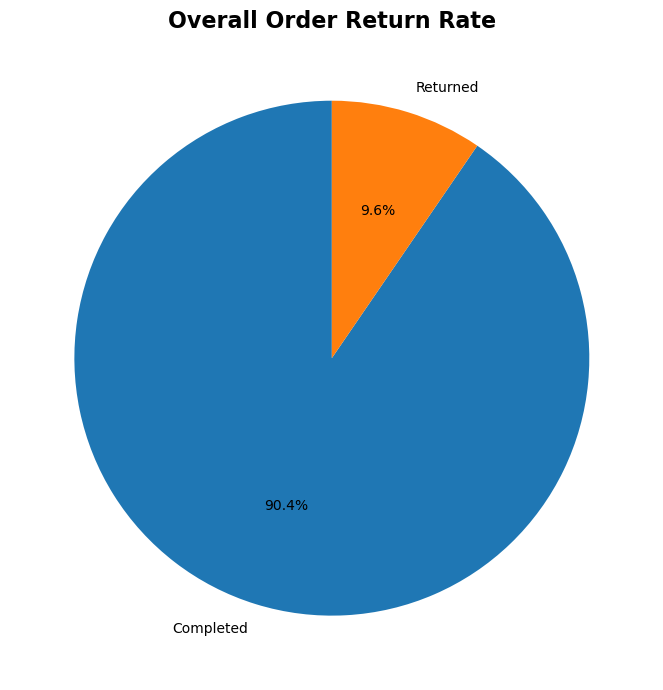

In [12]:
# Count orders by return status
return_counts = (
    orders["return_status"]
    .value_counts()
)

# Return rate
total_orders = len(orders)

returned_orders = return_counts.get("Returned", 0)

return_rate = (returned_orders / total_orders) * 100

print(f"Total Orders: {total_orders:,}")
print(f"Returned Orders: {returned_orders:,}")
print(f"Overall Return Rate: {return_rate:.2f}%")

# Pie chart
plt.figure(figsize=(7, 7))

plt.pie(
    return_counts.values,
    labels=return_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Order Return Rate",
          fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

####
### 4. DISCOUNT DISTRIBUTION

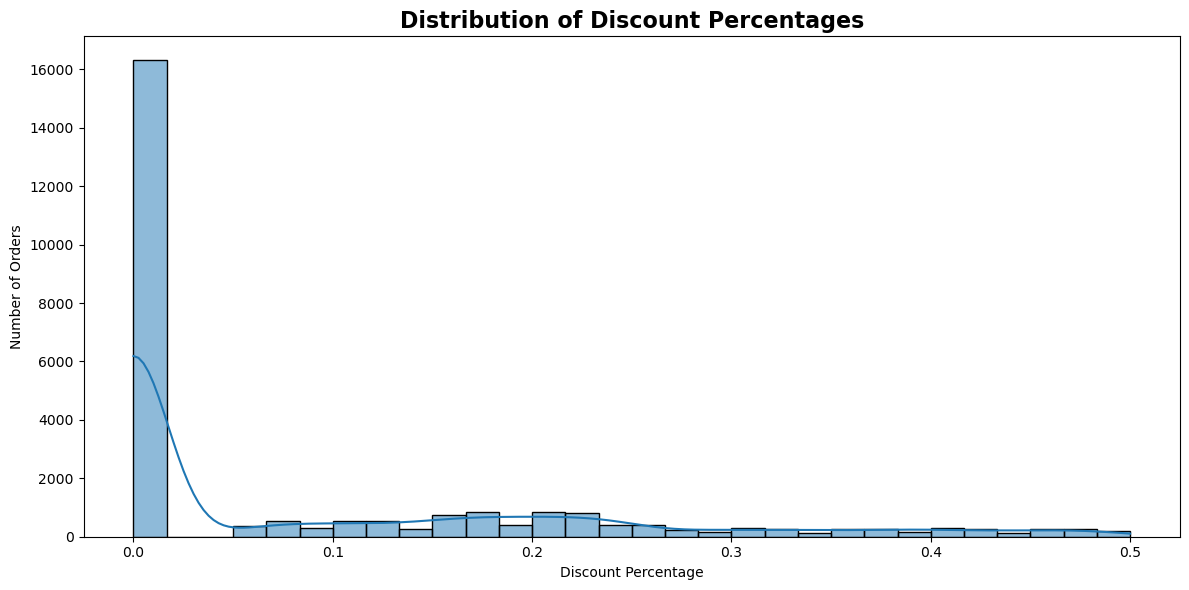

Discount Percentage Statistics:


,discount_pct
count,26500.000000
mean,0.089105
std,0.134476
min,0.000000
25%,0.000000
50%,0.000000
75%,0.170000
max,0.500000


In [13]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=orders,
    x="discount_pct",
    bins=30,
    kde=True
)

plt.title("Distribution of Discount Percentages",
          fontsize=16, fontweight="bold")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

# Discount statistics
discount_summary = orders["discount_pct"].describe()

print("Discount Percentage Statistics:")
display(discount_summary.to_frame())

####
### 5. GROSS SALES VS NET SALES — TOP 5 SUB-CATEGORIES

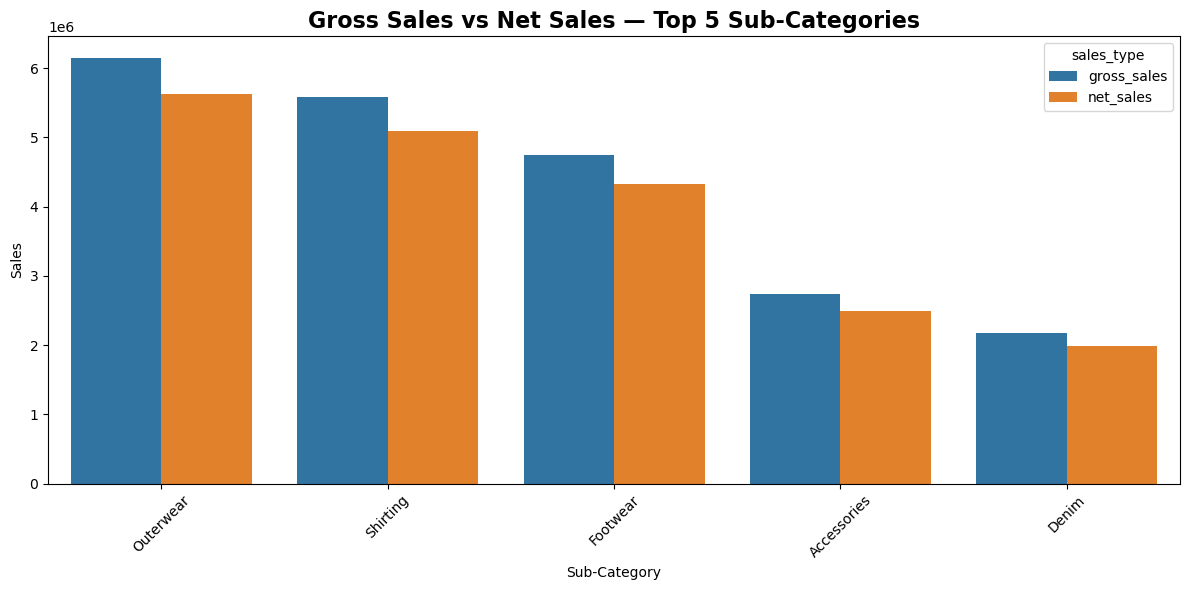


EDA SUMMARY — SALES & PROFITABILITY

1. Q4 Sales Contribution: 38.42%
2. Overall Return Rate: 9.55%
Top 5 Sub-Categories — Gross vs Net Sales:


,sub_category,gross_sales,net_sales,sales_difference,discount_impact_pct
3,Outerwear,6152096.65,5624501.04,527595.61,8.58
4,Shirting,5588954.42,5091237.78,497716.64,8.91
2,Footwear,4741193.60,4319792.79,421400.81,8.89
0,Accessories,2736217.33,2499178.77,237038.56,8.66
1,Denim,2171417.79,1989614.57,181803.22,8.37


In [16]:
# Merge Orders with Products
sales_subcategory = orders.merge(
    products[["product_id", "sub_category"]],
    on="product_id",
    how="left"
)

# Identify Top 5 sub-categories by Net Sales
top_5_subcategories = (
    sales_subcategory
    .groupby("sub_category")["net_sales"]
    .sum()
    .nlargest(5)
    .index
)

# Filter Top 5
top_5_sales = (
    sales_subcategory[
        sales_subcategory["sub_category"].isin(top_5_subcategories)
    ]
    .groupby("sub_category")
    [["gross_sales", "net_sales"]]
    .sum()
    .reset_index()
)

# Sort by Net Sales
top_5_sales = top_5_sales.sort_values(
    "net_sales",
    ascending=False
)

# Reshape for grouped bar chart
plot_data = top_5_sales.melt(
    id_vars="sub_category",
    value_vars=["gross_sales", "net_sales"],
    var_name="sales_type",
    value_name="sales"
)

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_data,
    x="sub_category",
    y="sales",
    hue="sales_type"
)

plt.title("Gross Sales vs Net Sales — Top 5 Sub-Categories",
          fontsize=16, fontweight="bold")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate discount/revenue impact
top_5_sales["sales_difference"] = (
    top_5_sales["gross_sales"] -
    top_5_sales["net_sales"]
)

top_5_sales["discount_impact_pct"] = (
    top_5_sales["sales_difference"] /
    top_5_sales["gross_sales"] *
    100
)

print("\n" + "=" * 70)
print("EDA SUMMARY — SALES & PROFITABILITY")
print("=" * 70)

print(f"\n1. Q4 Sales Contribution: {q4_sales_percentage:.2f}%")
print(f"2. Overall Return Rate: {return_rate:.2f}%")

print("Top 5 Sub-Categories — Gross vs Net Sales:")
display(
    top_5_sales.round(2)
)

####
### 6. CUSTOMER RFM ANALYSIS

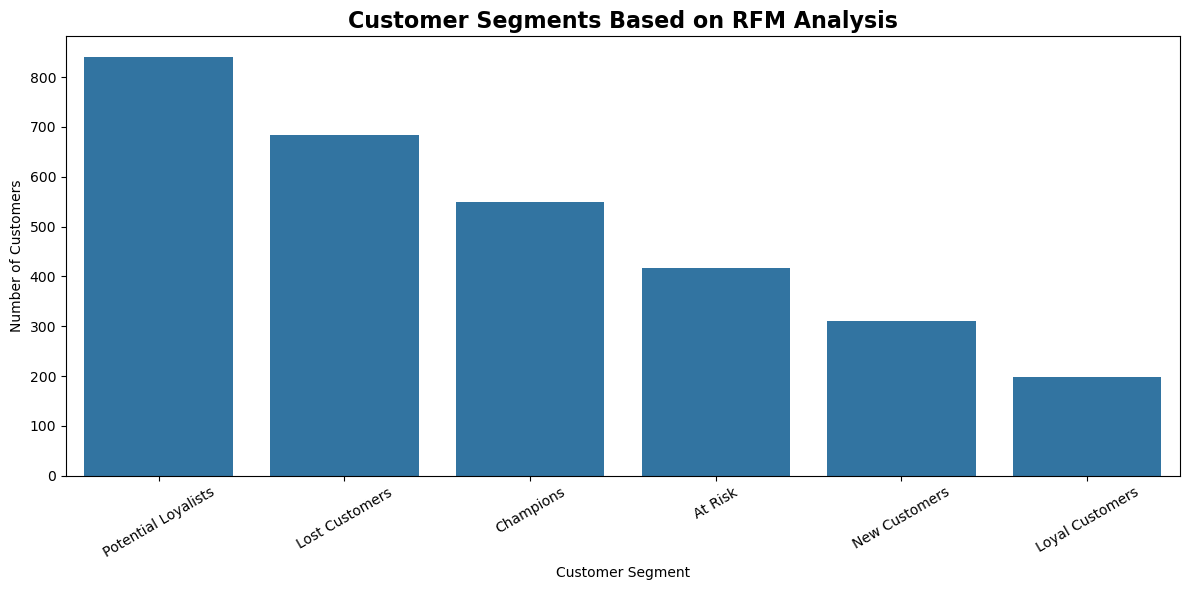

RFM Segment Distribution:


,Segment,Customer_Count
0,Potential Loyalists,840
1,Lost Customers,684
2,Champions,549
3,At Risk,417
4,New Customers,311
5,Loyal Customers,198



RFM Customer Data:


,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,1,674,1,943.68,1,1,1,111,Lost Customers
1,2,206,9,5894.80,1,4,3,143,At Risk
2,3,67,21,17486.98,2,5,5,255,At Risk
3,4,71,8,4765.38,2,3,3,233,At Risk
4,5,143,5,3154.55,2,1,2,212,Lost Customers


In [17]:
# Make sure order_date is datetime
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Reference date = day after the latest transaction
reference_date = orders["order_date"].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm = (
    orders
    .groupby("customer_id")
    .agg(
        Recency=("order_date", lambda x: (reference_date - x.max()).days),
        Frequency=("order_id", "nunique"),
        Monetary=("net_sales", "sum")
    )
    .reset_index()
)

# Create RFM scores using quintiles
# duplicates='drop' prevents errors when identical values create duplicate bins
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

# Overall RFM Score
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

# Create customer segments
def rfm_segment(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4 and m >= 4:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "New Customers"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2:
        return "Lost Customers"

    else:
        return "Potential Loyalists"


rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

# Segment sizes
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Customer_Count"]

# Plot segment sizes
plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_counts,
    x="Segment",
    y="Customer_Count"
)

plt.title("Customer Segments Based on RFM Analysis",
          fontsize=16, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("RFM Segment Distribution:")
display(segment_counts)

print("\nRFM Customer Data:")
display(rfm.head())

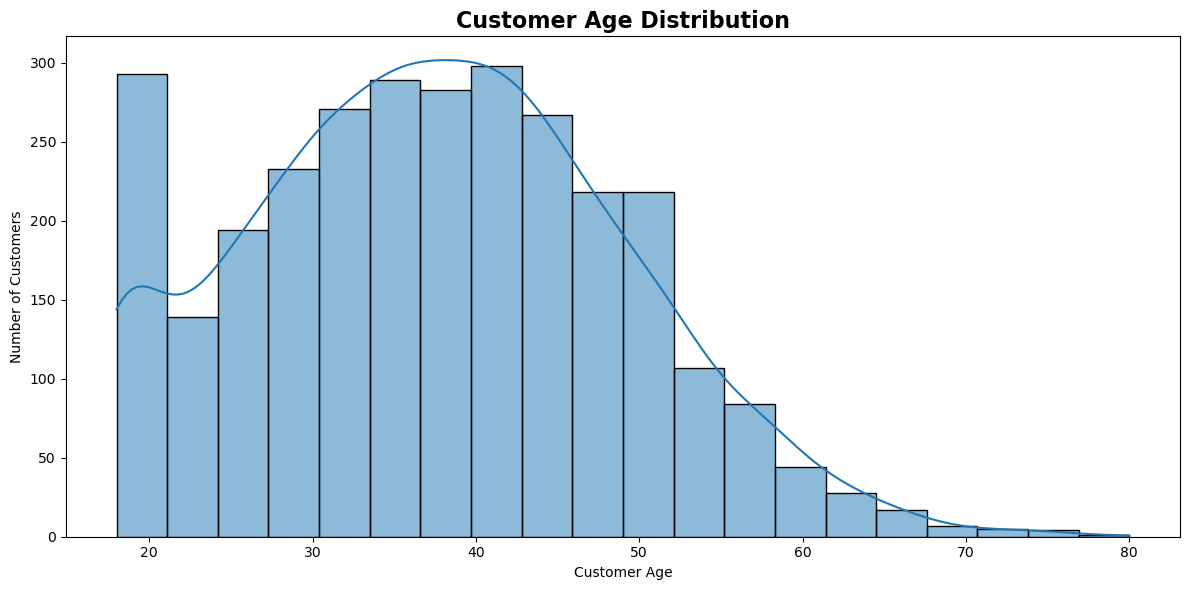

Customer Age Statistics:


count    3000.00
mean       37.51
std        11.40
min        18.00
25%        29.00
50%        37.00
75%        45.00
max        80.00
Name: age, dtype: float64

In [18]:
####
### 7. CUSTOMER AGE DISTRIBUTION


# Merge customer age information if required
customer_age = customers[["customer_id", "age"]].copy()

# Remove missing ages
customer_age = customer_age.dropna(subset=["age"])

plt.figure(figsize=(12, 6))

sns.histplot(
    data=customer_age,
    x="age",
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution",
          fontsize=16, fontweight="bold")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print("Customer Age Statistics:")
display(customer_age["age"].describe().round(2))

####
### 8. CUSTOMER DISTRIBUTION ACROSS LOYALTY TIERS

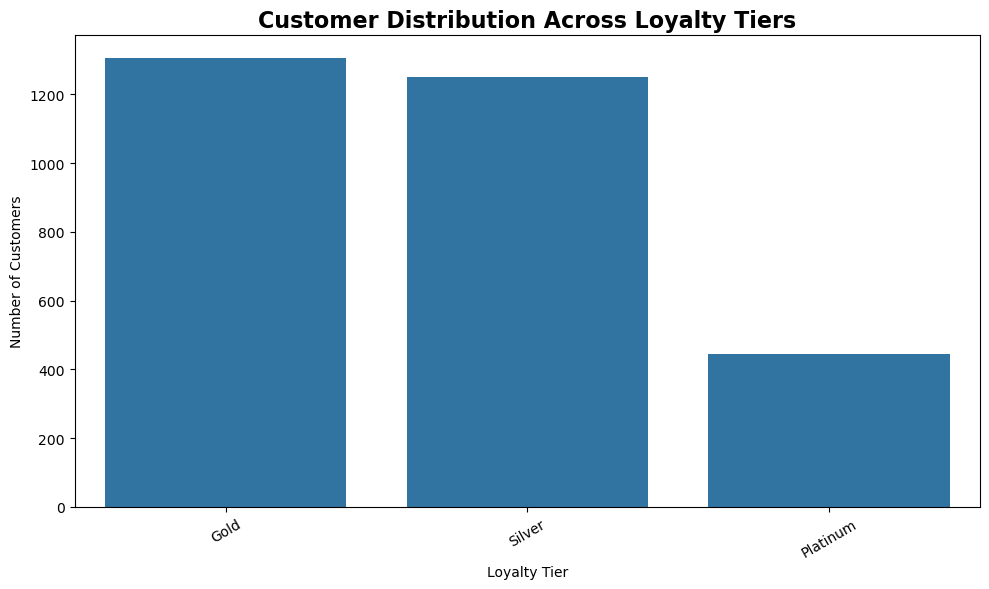

Loyalty Tier Distribution:


,Loyalty_Tier,Customer_Count
0,Gold,1306
1,Silver,1250
2,Platinum,444


In [20]:
loyalty_counts = (
    customers["loyalty_tier"]
    .value_counts()
    .reset_index()
)

loyalty_counts.columns = ["Loyalty_Tier", "Customer_Count"]

plt.figure(figsize=(10, 6))

sns.countplot(
    data=customers,
    x="loyalty_tier",
    order=customers["loyalty_tier"].value_counts().index
)

plt.title("Customer Distribution Across Loyalty Tiers",
          fontsize=16, fontweight="bold")
plt.xlabel("Loyalty Tier")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Loyalty Tier Distribution:")
display(loyalty_counts)

####
### 9. AVERAGE ORDER VALUE BY INCOME BRACKET

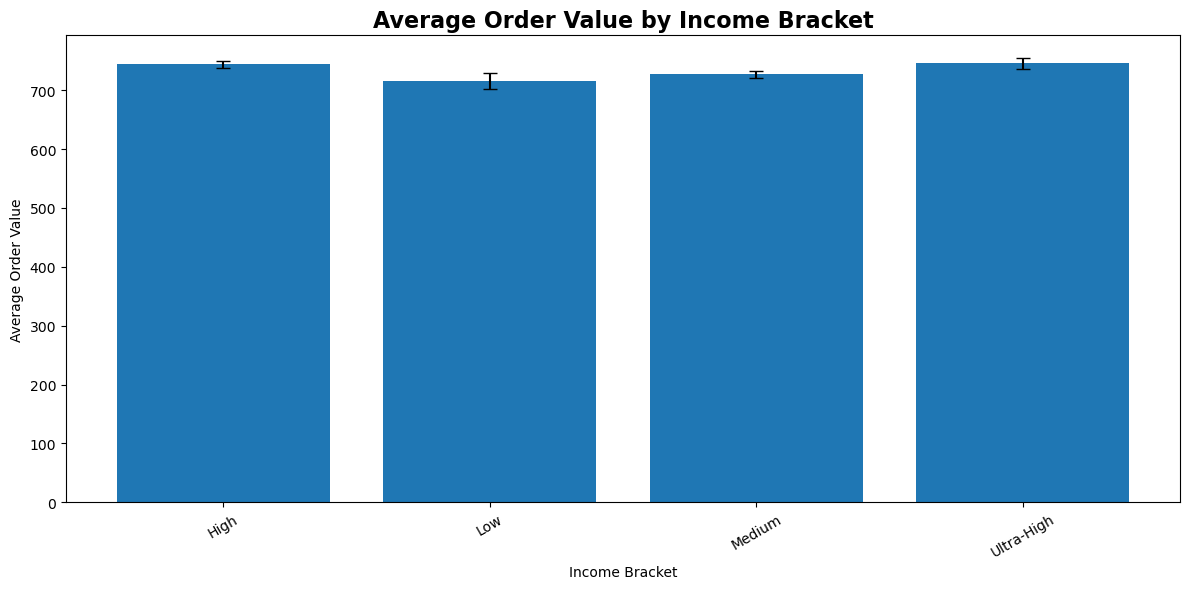

Average Order Value by Income Bracket:


,income_bracket,Mean_AOV,Std_AOV,Order_Count,SE
0,High,744.29,619.71,11566,5.76
1,Low,715.66,585.75,2046,12.95
2,Medium,726.76,597.58,8458,6.50
3,Ultra-High,745.96,631.21,4430,9.48


In [21]:
# Merge income bracket with orders
orders_income = orders.merge(
    customers[["customer_id", "income_bracket"]],
    on="customer_id",
    how="left"
)

# Calculate Order Value at individual order level
order_values = (
    orders_income
    .groupby(
        ["income_bracket", "order_id"],
        as_index=False
    )["net_sales"]
    .sum()
)

# Calculate average order value and standard deviation
aov_summary = (
    order_values
    .groupby("income_bracket")["net_sales"]
    .agg(
        Mean_AOV="mean",
        Std_AOV="std",
        Order_Count="count"
    )
    .reset_index()
)

# Standard Error
aov_summary["SE"] = (
    aov_summary["Std_AOV"] /
    np.sqrt(aov_summary["Order_Count"])
)

# Plot with error bars
plt.figure(figsize=(12, 6))

plt.bar(
    aov_summary["income_bracket"],
    aov_summary["Mean_AOV"],
    yerr=aov_summary["SE"],
    capsize=5
)

plt.title("Average Order Value by Income Bracket",
          fontsize=16, fontweight="bold")
plt.xlabel("Income Bracket")
plt.ylabel("Average Order Value")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Average Order Value by Income Bracket:")
display(
    aov_summary[
        [
            "income_bracket",
            "Mean_AOV",
            "Std_AOV",
            "Order_Count",
            "SE"
        ]
    ].round(2)
)

####
### 10. ORDER COUNTS BY ACQUISITION SOURCE

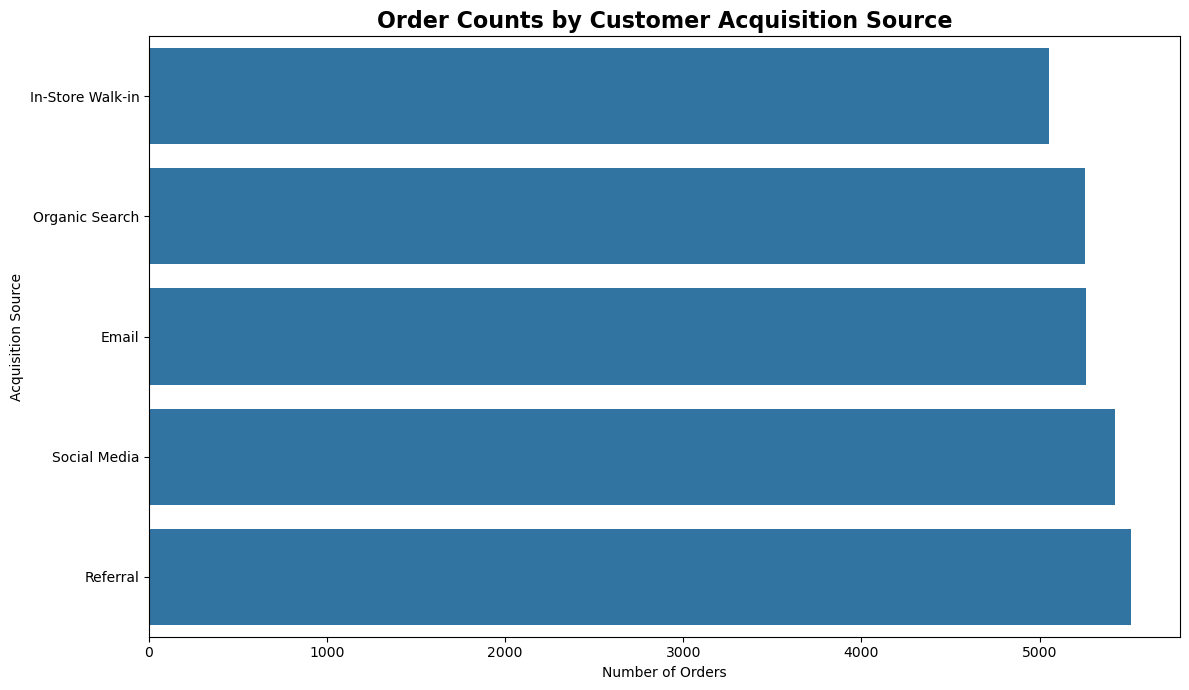

Order Counts by Acquisition Source:


,Acquisition_Source,Order_Count
0,In-Store Walk-in,5051
1,Organic Search,5255
2,Email,5260
3,Social Media,5421
4,Referral,5513


In [22]:
# Merge acquisition source with orders
orders_acquisition = orders.merge(
    customers[["customer_id", "acquisition_source"]],
    on="customer_id",
    how="left"
)

# Count orders by acquisition source
acquisition_orders = (
    orders_acquisition
    .groupby("acquisition_source")["order_id"]
    .nunique()
    .sort_values(ascending=True)
    .reset_index()
)

acquisition_orders.columns = [
    "Acquisition_Source",
    "Order_Count"
]

# Horizontal bar chart
plt.figure(figsize=(12, 7))

sns.barplot(
    data=acquisition_orders,
    x="Order_Count",
    y="Acquisition_Source"
)

plt.title("Order Counts by Customer Acquisition Source",
          fontsize=16, fontweight="bold")
plt.xlabel("Number of Orders")
plt.ylabel("Acquisition Source")
plt.tight_layout()
plt.show()

print("Order Counts by Acquisition Source:")
display(acquisition_orders)

####
#### STORES & OPERATIONS

In [23]:
# Make sure date columns are in datetime format
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["delivery_date"] = pd.to_datetime(orders["delivery_date"])

####
### 11. AVERAGE E-COMMERCE DELIVERY TIME

Average E-Commerce Delivery Time: 3.50 days


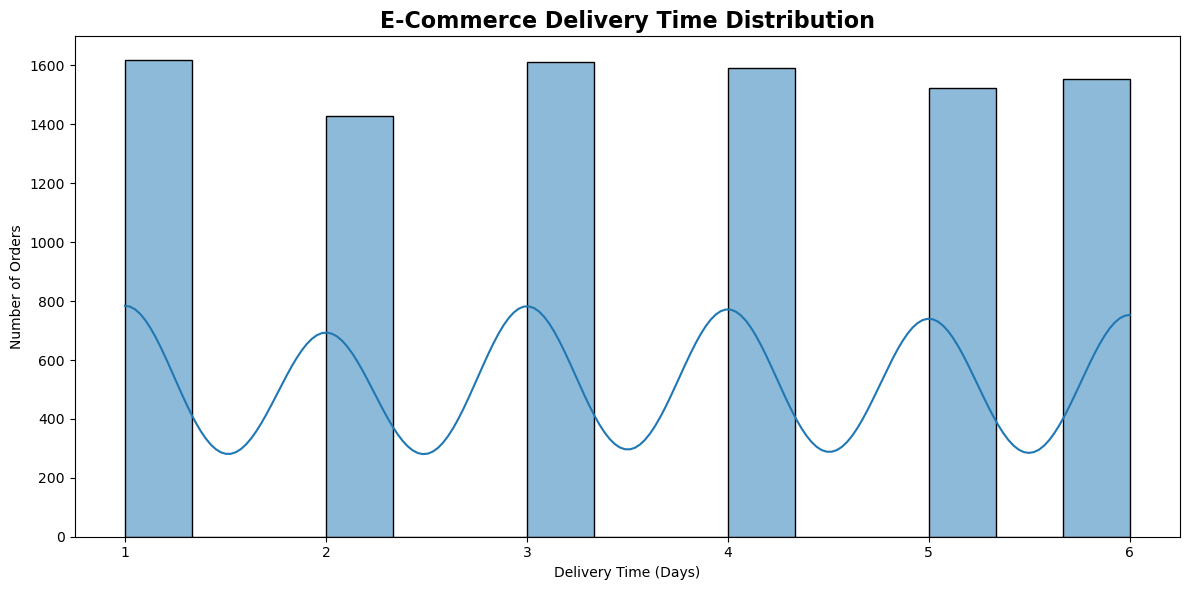

Delivery Time Statistics:


count    9329.00
mean        3.50
std         1.71
min         1.00
25%         2.00
50%         4.00
75%         5.00
max         6.00
Name: delivery_time_days, dtype: float64

In [24]:
# Get E-Commerce store IDs
ecommerce_store_ids = stores.loc[
    stores["store_type"].str.lower().eq("e-commerce"),
    "store_id"
]

# Filter E-Commerce orders
ecommerce_orders = orders[
    orders["store_id"].isin(ecommerce_store_ids)
].copy()

# Calculate delivery time in days
ecommerce_orders["delivery_time_days"] = (
    ecommerce_orders["delivery_date"] -
    ecommerce_orders["order_date"]
).dt.days

# Remove invalid/missing delivery times
ecommerce_delivery = ecommerce_orders[
    ecommerce_orders["delivery_time_days"].notna() &
    (ecommerce_orders["delivery_time_days"] >= 0)
].copy()

print(
    f"Average E-Commerce Delivery Time: "
    f"{ecommerce_delivery['delivery_time_days'].mean():.2f} days"
)

# Distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    data=ecommerce_delivery,
    x="delivery_time_days",
    bins=15,
    kde=True
)

plt.title(
    "E-Commerce Delivery Time Distribution",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

print("Delivery Time Statistics:")
display(
    ecommerce_delivery["delivery_time_days"]
    .describe()
    .round(2)
)

####
### 12. PHYSICAL STOCK LEVEL BY STORE TYPE

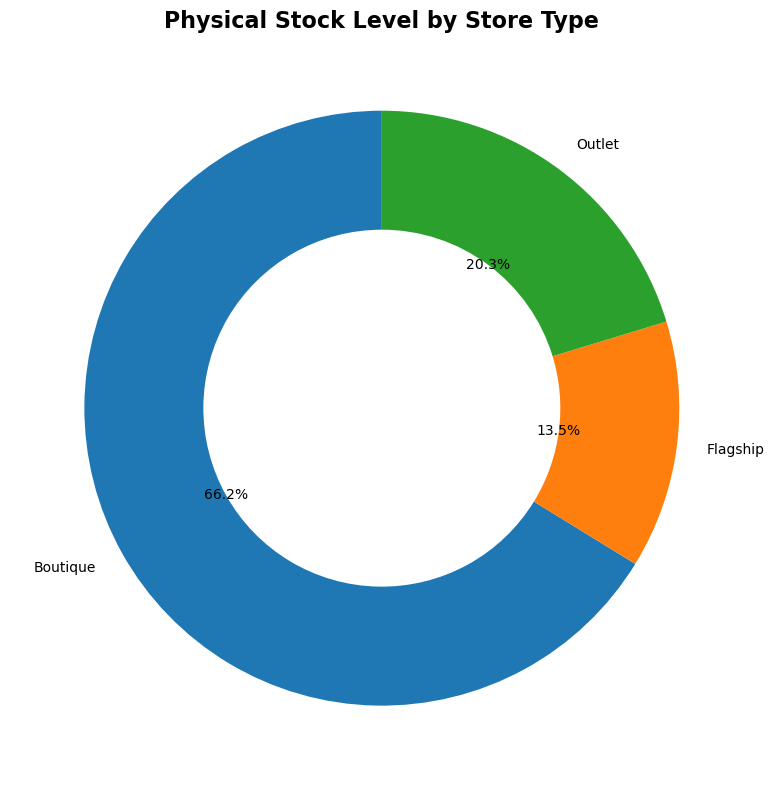

Physical Stock by Store Type:


,store_type,stock_level
0,Boutique,47496
1,Flagship,9660
2,Outlet,14557


In [25]:
# Exclude E-Commerce because it does not represent physical store stock
physical_inventory = inventory.merge(
    stores[["store_id", "store_type"]],
    on="store_id",
    how="left"
)

physical_inventory = physical_inventory[
    physical_inventory["store_type"].str.lower() != "e-commerce"
].copy()

# Total stock by store type
stock_by_type = (
    physical_inventory
    .groupby("store_type")["stock_level"]
    .sum()
    .reset_index()
)

# Donut chart
plt.figure(figsize=(8, 8))

plt.pie(
    stock_by_type["stock_level"],
    labels=stock_by_type["store_type"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.40}
)

plt.title(
    "Physical Stock Level by Store Type",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print("Physical Stock by Store Type:")
display(stock_by_type)

####
### 13. STORE SQUARE FOOTAGE VS TOTAL REVENUE

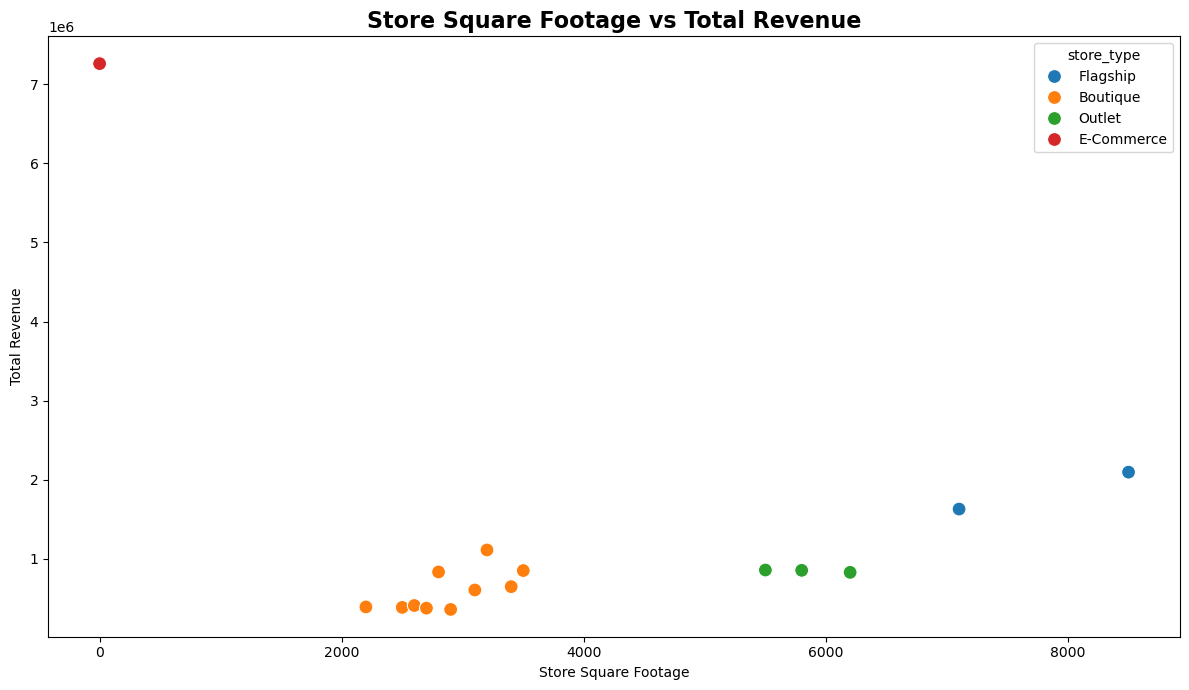

Store Spatial Efficiency:


,store_id,store_type,square_footage,total_revenue,revenue_per_sqft
1,2,Boutique,3200,1113322.17,347.91
3,4,Boutique,2800,835598.22,298.43
0,1,Flagship,8500,2096715.85,246.67
5,6,Boutique,3500,852964.65,243.70
2,3,Flagship,7100,1630355.06,229.63
6,7,Boutique,3100,607521.91,195.97
7,8,Boutique,3400,649799.53,191.12
10,11,Boutique,2200,393458.03,178.84
12,13,Boutique,2600,411554.91,158.29
4,5,Outlet,5500,859765.08,156.32


In [26]:
# Calculate revenue by store
store_revenue = (
    orders
    .groupby("store_id")["net_sales"]
    .sum()
    .reset_index()
    .rename(columns={"net_sales": "total_revenue"})
)

# Merge with store information
store_efficiency = stores.merge(
    store_revenue,
    on="store_id",
    how="left"
)

store_efficiency["total_revenue"] = (
    store_efficiency["total_revenue"]
    .fillna(0)
)

# Scatter plot
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=store_efficiency,
    x="square_footage",
    y="total_revenue",
    hue="store_type",
    s=100
)

plt.title(
    "Store Square Footage vs Total Revenue",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Store Square Footage")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

# Revenue per square foot
store_efficiency["revenue_per_sqft"] = np.where(
    store_efficiency["square_footage"] > 0,
    store_efficiency["total_revenue"] /
    store_efficiency["square_footage"],
    np.nan
)

print("Store Spatial Efficiency:")
display(
    store_efficiency[
        [
            "store_id",
            "store_type",
            "square_footage",
            "total_revenue",
            "revenue_per_sqft"
        ]
    ]
    .sort_values("revenue_per_sqft", ascending=False)
    .round(2)
)

####
### 14. ORDER STATUS BY STORE CITY

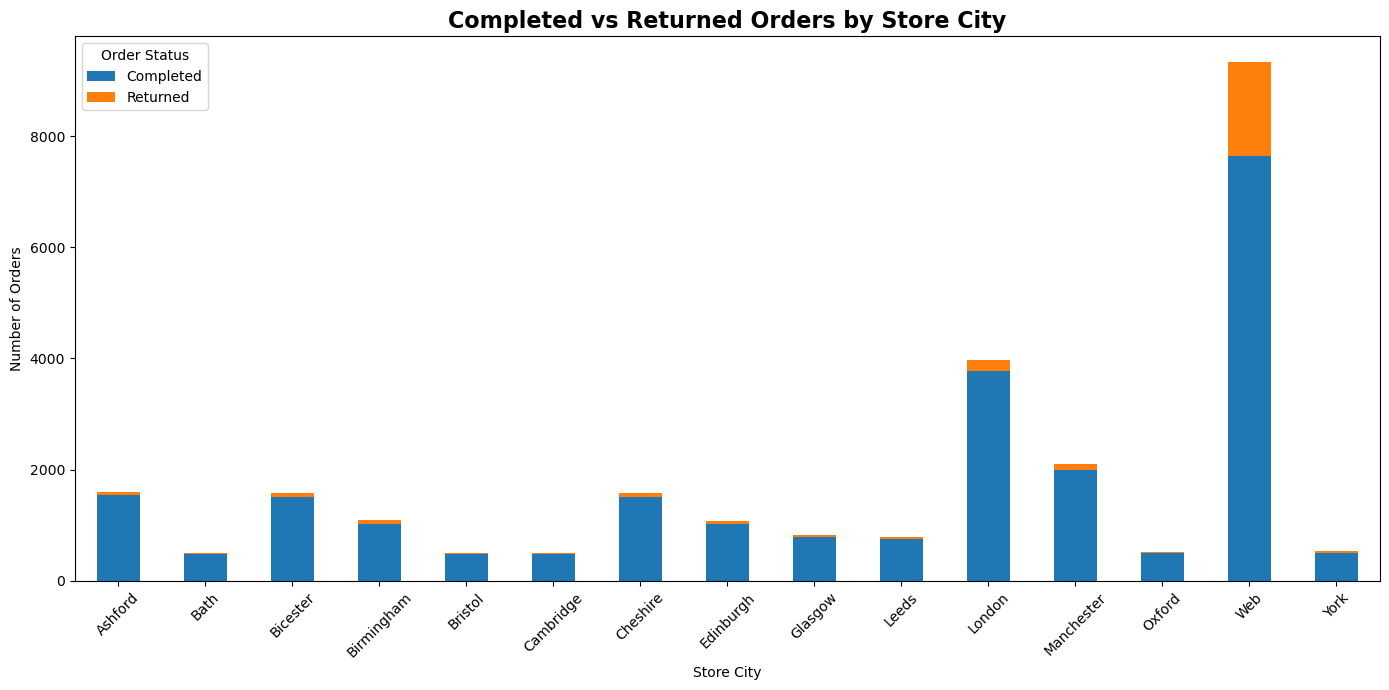

Order Status by City:


order_status,Completed,Returned
city,,
Ashford,1535,71
Bath,480,20
Bicester,1508,75
Birmingham,1022,64
Bristol,479,16
Cambridge,479,25
Cheshire,1511,76
Edinburgh,1020,60
Glasgow,781,44


In [27]:
# Merge store city with orders
orders_city = orders.merge(
    stores[["store_id", "city"]],
    on="store_id",
    how="left"
)

# Standardize order status from return_status
orders_city["order_status"] = np.where(
    orders_city["return_status"].str.lower().eq("returned"),
    "Returned",
    "Completed"
)

# Count orders by city and status
city_status = (
    orders_city
    .groupby(["city", "order_status"])["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

# Pivot for stacked chart
city_status_pivot = (
    city_status
    .pivot(
        index="city",
        columns="order_status",
        values="order_count"
    )
    .fillna(0)
)

# Make sure both categories exist
for status in ["Completed", "Returned"]:
    if status not in city_status_pivot.columns:
        city_status_pivot[status] = 0

city_status_pivot = city_status_pivot[
    ["Completed", "Returned"]
]

# Stacked bar chart
city_status_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title(
    "Completed vs Returned Orders by Store City",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Store City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.legend(title="Order Status")
plt.tight_layout()
plt.show()

print("Order Status by City:")
display(city_status_pivot)

####
### 15. TOP 3 STORES WITH LOW-RATING ORDERS

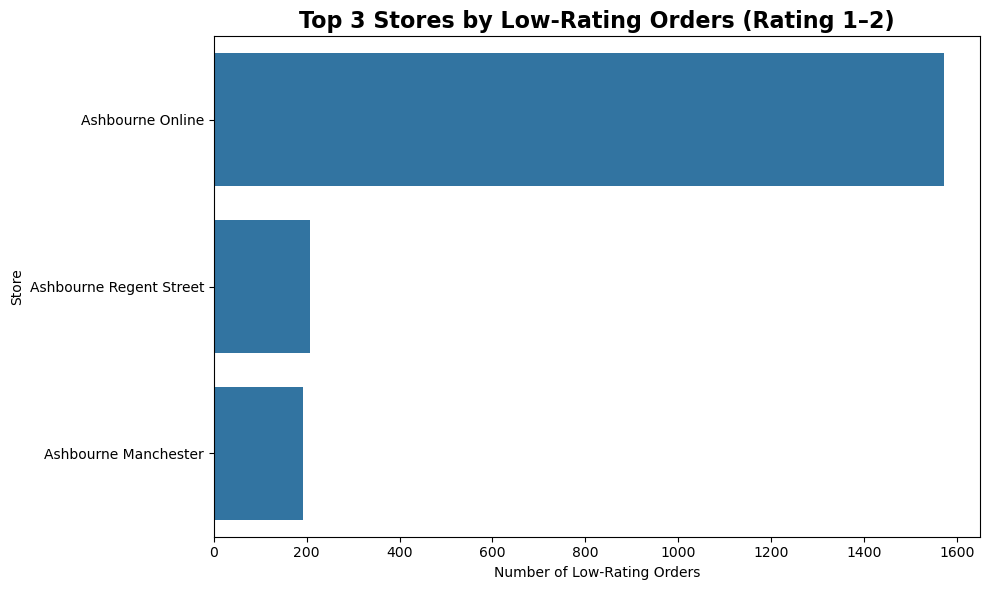

Top 3 Stores with Highest Low-Rating Order Volume:


,store_id,low_rating_order_count,store_name,city
15,16,1571,Ashbourne Online,Web
0,1,208,Ashbourne Regent Street,London
2,3,193,Ashbourne Manchester,Manchester


In [28]:
# Filter ratings 1 and 2
low_rating_orders = orders[
    orders["rating"].isin([1, 2])
].copy()

# Count low-rating orders by store
low_rating_store = (
    low_rating_orders
    .groupby("store_id")["order_id"]
    .nunique()
    .reset_index(name="low_rating_order_count")
)

# Add store information
low_rating_store = low_rating_store.merge(
    stores[
        [
            "store_id",
            "store_name",
            "city"
        ]
    ],
    on="store_id",
    how="left"
)

# Top 3
top_3_low_rating = (
    low_rating_store
    .sort_values(
        "low_rating_order_count",
        ascending=False
    )
    .head(3)
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_3_low_rating,
    x="low_rating_order_count",
    y="store_name"
)

plt.title(
    "Top 3 Stores by Low-Rating Orders (Rating 1–2)",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Number of Low-Rating Orders")
plt.ylabel("Store")
plt.tight_layout()
plt.show()

print("Top 3 Stores with Highest Low-Rating Order Volume:")
display(top_3_low_rating)


####
### 16. UNIT COST VS RETAIL PRICE

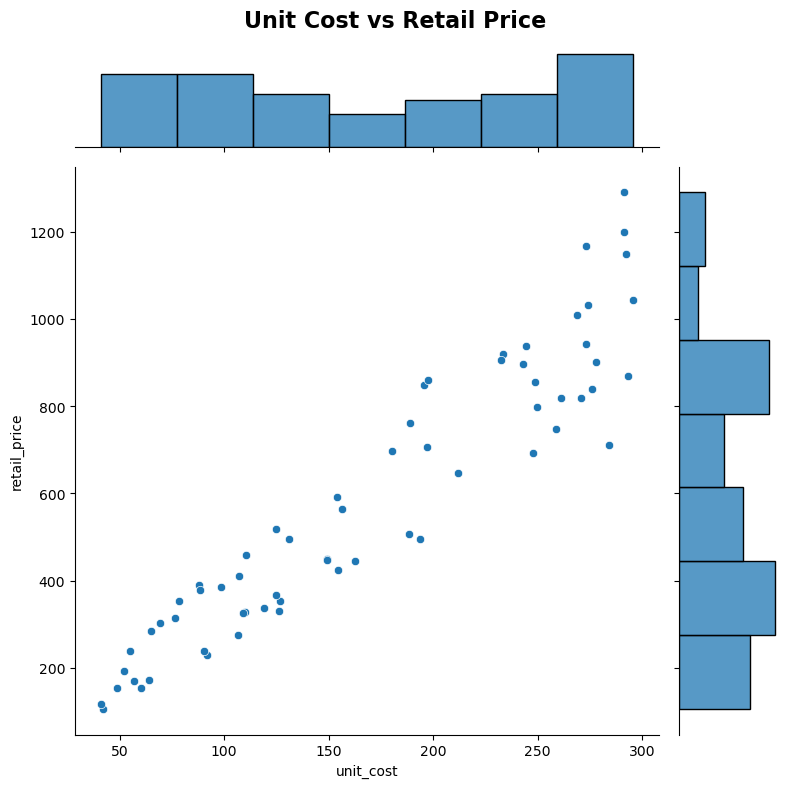

In [29]:
# Select required product columns
price_data = products[
    ["product_id", "unit_cost", "retail_price"]
].dropna()

# Joint plot
g = sns.jointplot(
    data=price_data,
    x="unit_cost",
    y="retail_price",
    kind="scatter",
    height=8
)

g.fig.suptitle(
    "Unit Cost vs Retail Price",
    fontsize=16,
    fontweight="bold"
)

g.fig.tight_layout()
g.fig.subplots_adjust(top=0.93)

plt.show()

####
### 17. REVENUE BY MARKETING CAMPAIGN CHANNEL

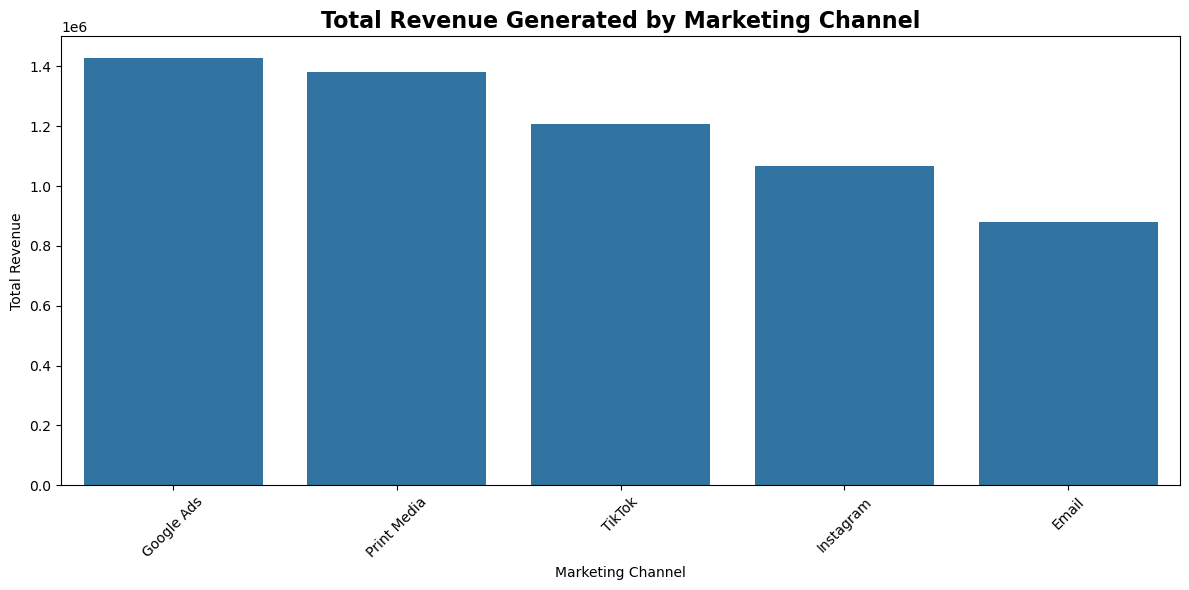

Revenue by Marketing Channel:


,channel,total_revenue
0,Google Ads,1429155.24
1,Print Media,1381809.13
2,TikTok,1207366.82
3,Instagram,1068714.54
4,Email,881088.93


In [30]:
# Merge orders with campaign information
campaign_revenue = orders.merge(
    marketing_campaigns[
        [
            "campaign_id",
            "channel"
        ]
    ],
    on="campaign_id",
    how="left"
)

# Calculate revenue by channel
channel_revenue = (
    campaign_revenue
    .dropna(subset=["channel"])
    .groupby("channel")["net_sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

channel_revenue.columns = [
    "channel",
    "total_revenue"
]

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=channel_revenue,
    x="channel",
    y="total_revenue"
)

plt.title(
    "Total Revenue Generated by Marketing Channel",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Marketing Channel")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Revenue by Marketing Channel:")
display(channel_revenue.round(2))


####
### 18. AVERAGE RATING BY PRODUCT MATERIAL

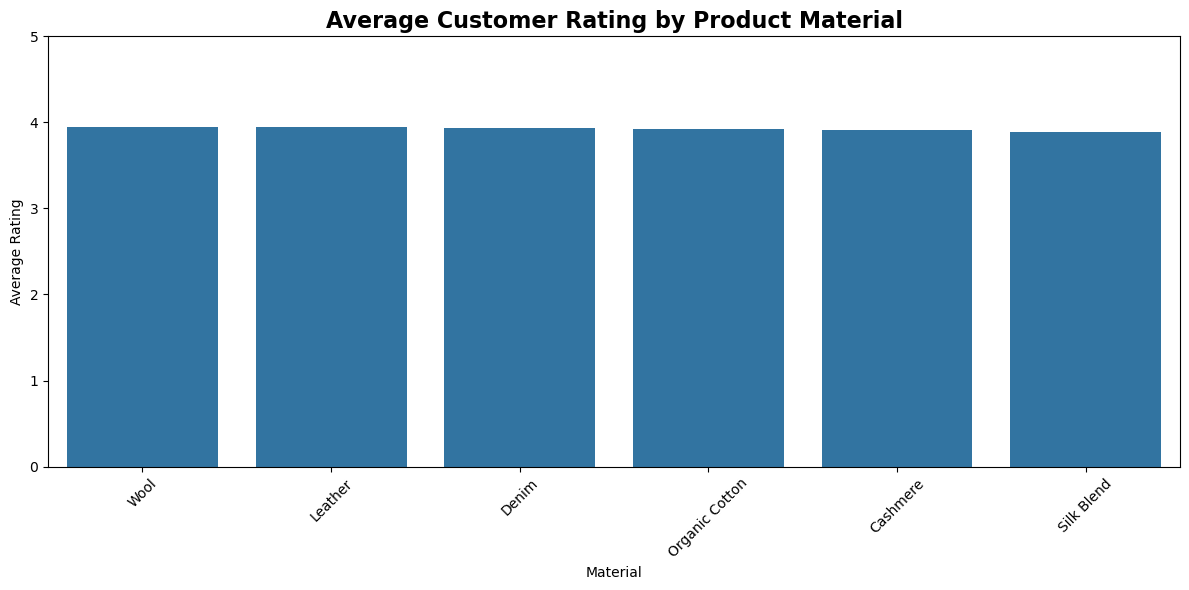

Average Rating by Material:


,material,average_rating,rating_count
5,Wool,3.95,3685
2,Leather,3.94,2938
1,Denim,3.93,5473
3,Organic Cotton,3.93,4018
0,Cashmere,3.91,5809
4,Silk Blend,3.89,4577


In [31]:
# Merge product material with order ratings
material_rating = orders.merge(
    products[
        [
            "product_id",
            "material"
        ]
    ],
    on="product_id",
    how="left"
)

# Calculate average rating
material_summary = (
    material_rating
    .dropna(subset=["material", "rating"])
    .groupby("material")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
    .sort_values(
        "average_rating",
        ascending=False
    )
)

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=material_summary,
    x="material",
    y="average_rating"
)

plt.title(
    "Average Customer Rating by Product Material",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Material")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Average Rating by Material:")
display(material_summary.round(2))

####
### 19. CAMPAIGN BUDGET VS ACTUAL REVENUE

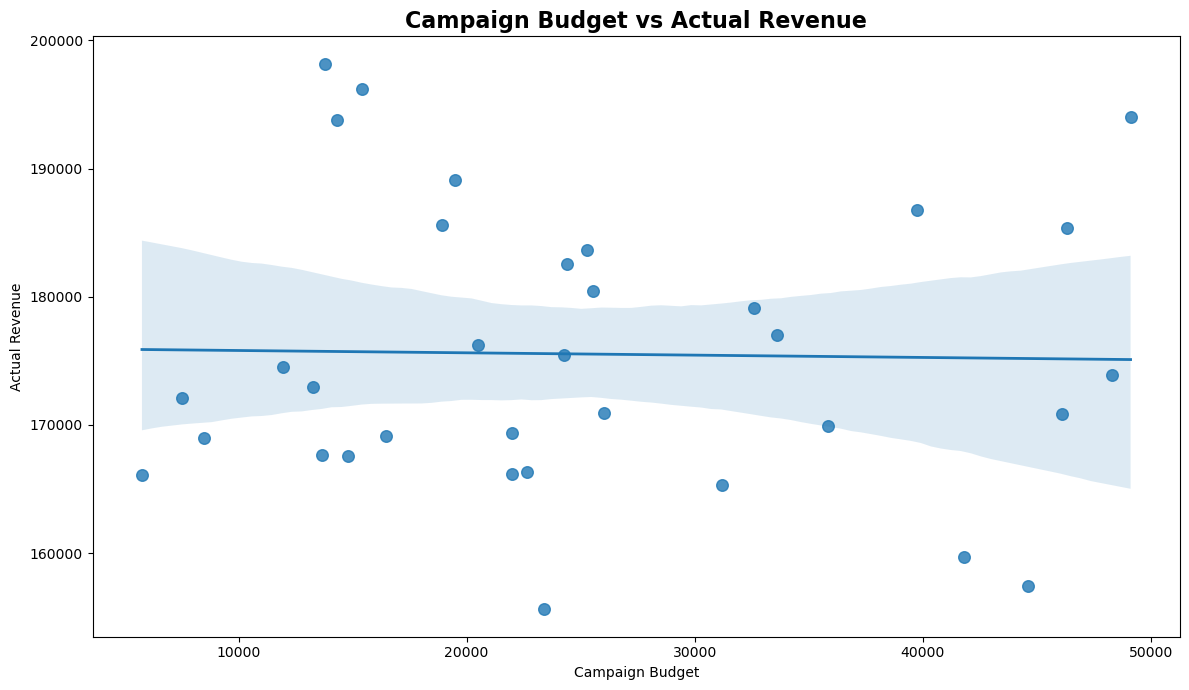

Campaign Budget vs Actual Revenue Correlation: -0.021

Campaign Performance:


,campaign_id,budget,actual_revenue
4,5,13797.62,198189.58
10,11,15409.39,196216.22
16,17,49114.81,194038.27
2,3,14332.01,193790.11
20,21,19484.58,189117.27
29,30,39752.45,186795.78
1,2,18907.44,185619.64
15,16,46332.96,185341.14
19,20,25263.44,183652.36
17,18,24396.95,182572.47


In [32]:
# Campaign revenue
campaign_actual_revenue = (
    orders
    .groupby("campaign_id")["net_sales"]
    .sum()
    .reset_index()
    .rename(
        columns={
            "net_sales": "actual_revenue"
        }
    )
)

# Merge with campaign budgets
campaign_performance = marketing_campaigns.merge(
    campaign_actual_revenue,
    on="campaign_id",
    how="left"
)

campaign_performance["actual_revenue"] = (
    campaign_performance["actual_revenue"]
    .fillna(0)
)

campaign_performance = campaign_performance.dropna(
    subset=["budget"]
)

# Scatter plot with regression line
plt.figure(figsize=(12, 7))

sns.regplot(
    data=campaign_performance,
    x="budget",
    y="actual_revenue",
    scatter_kws={"s": 70},
    line_kws={"linewidth": 2}
)

plt.title(
    "Campaign Budget vs Actual Revenue",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Campaign Budget")
plt.ylabel("Actual Revenue")
plt.tight_layout()
plt.show()

# Correlation
campaign_correlation = campaign_performance[
    ["budget", "actual_revenue"]
].corr().iloc[0, 1]

print(
    f"Campaign Budget vs Actual Revenue Correlation: "
    f"{campaign_correlation:.3f}"
)

print("\nCampaign Performance:")
display(
    campaign_performance[
        [
            "campaign_id",
            "budget",
            "actual_revenue"
        ]
    ].sort_values(
        "actual_revenue",
        ascending=False
    ).round(2)
)


####
### 20. CAMPAIGN START DATES VS DAILY ORDER VOLUME

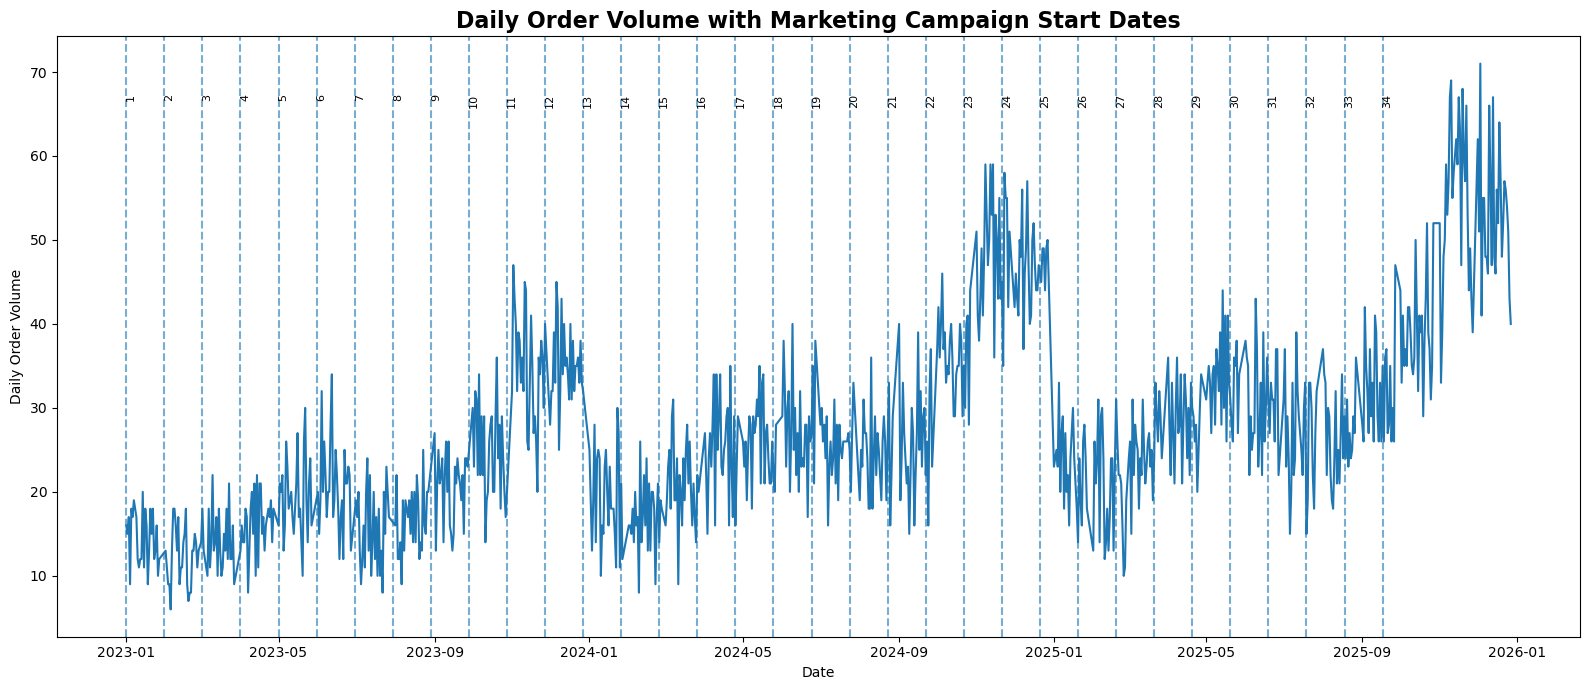

In [33]:
# Daily order volume
daily_orders = (
    orders
    .groupby(
        orders["order_date"].dt.normalize()
    )["order_id"]
    .nunique()
    .reset_index()
)

daily_orders.columns = [
    "date",
    "order_volume"
]

# Campaign start dates
campaign_dates = marketing_campaigns[
    ["campaign_id", "start_date"]
].copy()

campaign_dates["start_date"] = pd.to_datetime(
    campaign_dates["start_date"]
)

campaign_dates = campaign_dates.dropna(
    subset=["start_date"]
)

# Plot daily order volume
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=daily_orders,
    x="date",
    y="order_volume",
    linewidth=1.5
)

# Mark campaign start dates
for i, row in campaign_dates.iterrows():

    plt.axvline(
        x=row["start_date"],
        linestyle="--",
        alpha=0.6
    )

    # Add campaign label near top
    plt.text(
        row["start_date"],
        daily_orders["order_volume"].max() * 0.95,
        str(row["campaign_id"]),
        rotation=90,
        verticalalignment="top",
        fontsize=8
    )

plt.title(
    "Daily Order Volume with Marketing Campaign Start Dates",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Daily Order Volume")
plt.tight_layout()
plt.show()

####
# FINAL SUMMARY

In [34]:
print("\n" + "=" * 75)
print("PYTHON EDA — STORES, OPERATIONS, PRODUCTS & MARKETING")
print("=" * 75)

print(
    f"\nAverage E-Commerce Delivery Time: "
    f"{ecommerce_delivery['delivery_time_days'].mean():.2f} days"
)

print("\nTop 3 Stores by Low-Rating Orders:")
display(
    top_3_low_rating[
        [
            "store_id",
            "store_name",
            "city",
            "low_rating_order_count"
        ]
    ]
)

print("\nTop Marketing Channels by Revenue:")
display(
    channel_revenue.head(5).round(2)
)

print("\nHighest Average-Rated Materials:")
display(
    material_summary.head(5).round(2)
)

print(
    f"\nCampaign Budget vs Actual Revenue Correlation: "
    f"{campaign_correlation:.3f}"
)


PYTHON EDA — STORES, OPERATIONS, PRODUCTS & MARKETING

Average E-Commerce Delivery Time: 3.50 days

Top 3 Stores by Low-Rating Orders:


,store_id,store_name,city,low_rating_order_count
15,16,Ashbourne Online,Web,1571
0,1,Ashbourne Regent Street,London,208
2,3,Ashbourne Manchester,Manchester,193



Top Marketing Channels by Revenue:


,channel,total_revenue
0,Google Ads,1429155.24
1,Print Media,1381809.13
2,TikTok,1207366.82
3,Instagram,1068714.54
4,Email,881088.93



Highest Average-Rated Materials:


,material,average_rating,rating_count
5,Wool,3.95,3685
2,Leather,3.94,2938
1,Denim,3.93,5473
3,Organic Cotton,3.93,4018
0,Cashmere,3.91,5809



Campaign Budget vs Actual Revenue Correlation: -0.021


###### ------------------------------------------------------------------------------------------------------------ THE END ------------------------------------------------------------------------------------------------------------